<a href="https://colab.research.google.com/github/banteamlak1888/Fundamentals-for-AI/blob/main/Student_Performance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Deep Learning for Classification**
**Student Performance Prediction Using Artificial Neural Networks**

In [ ]:
# Import NumPy for numerical operations
import numpy as np

# Import Pandas for creating and handling datasets
import pandas as pd

# Import Matplotlib for plotting graphs
import matplotlib.pyplot as plt

# Import train_test_split to split data into training and testing sets
from sklearn.model_selection import train_test_split

# Import StandardScaler to scale numerical features
from sklearn.preprocessing import StandardScaler

# Import TensorFlow for deep learning
import tensorflow as tf

# Import Keras tools from TensorFlow
from tensorflow import keras
from tensorflow.keras import layers

**Step 1: Upload and Read Dataset**

This allows you to upload student_performance_dataset.csv into Google Colab.

In [ ]:
# Import files module from Google Colab
from google.colab import files

# Open file upload option
uploaded = files.upload()

Saving student_performance_dataset.csv to student_performance_dataset.csv


This confirms that the dataset is loaded correctly.

In [ ]:
# Import pandas for reading and handling dataset
import pandas as pd

# Read the uploaded CSV file
data = pd.read_csv("student_performance_dataset.csv")

# Display the first five rows
print(data.head())

   study_hours  attendance  assignment_score  previous_score  participation  \
0     3.745401   51.107976         26.170568       67.270299       5.719959   
1     9.507143   72.514057         24.697880       79.668140       8.054323   
2     7.319939   92.376750         90.625458       25.046790       7.601609   
3     5.986585   83.933493         24.954620       62.487410       1.538999   
4     1.560186   88.393669         27.194973       57.174598       1.492495   

   passed  
0       1  
1       1  
2       1  
3       1  
4       1  


**Step 2: Import Required Libraries**

These libraries help us prepare the data, build the neural network, train it, improve it, and evaluate performance.

In [ ]:
# Import NumPy for numerical operations
import numpy as np

# Import Matplotlib for visualization
import matplotlib.pyplot as plt

# Import train_test_split for splitting dataset
from sklearn.model_selection import train_test_split

# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

# Import evaluation tools
from sklearn.metrics import confusion_matrix, classification_report

# Import TensorFlow
import tensorflow as tf

# Import Keras tools
from tensorflow import keras
from tensorflow.keras import layers

**Step 3: Inspect the Dataset**

Before modeling, we check whether the dataset is complete and whether pass/fail classes are balanced.



In [ ]:
# Show dataset size
print("Dataset shape:", data.shape)

# Show column names
print("Columns:", data.columns.tolist())

# Check missing values
print(data.isnull().sum())

# Show target distribution
print(data["passed"].value_counts())

Dataset shape: (1000, 6)
Columns: ['study_hours', 'attendance', 'assignment_score', 'previous_score', 'participation', 'passed']
study_hours         0
attendance          0
assignment_score    0
previous_score      0
participation       0
passed              0
dtype: int64
passed
1    780
0    220
Name: count, dtype: int64


**Step 4: Separate Features and Target**  

X contains the student features, while y contains whether the student passed or failed.

In [ ]:
# Store all input columns except the target
X = data.drop("passed", axis=1)

# Store the target column
y = data["passed"]

In [ ]:
# Count how many students passed and failed
print(data["passed"].value_counts())

passed
1    780
0    220
Name: count, dtype: int64


**Step 5: Split Dataset**

We use 80% of the data for training and 20% for testing. stratify=y keeps the same pass/fail ratio in both sets.

In [ ]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Step 6: Scale the Features**

Scaling makes all features comparable. This helps neural networks train faster and more reliably.

In [ ]:
# Create scaler object
scaler = StandardScaler()

# Fit scaler on training data and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

**Step 7: Build a Basic Model First**

This is the baseline model from the previous project. We will compare it with the improved model.

In [ ]:
# Create a basic neural network model
basic_model = keras.Sequential([

    # Input layer based on number of features
    layers.Input(shape=(X_train_scaled.shape[1],)),

    # First hidden layer
    layers.Dense(16, activation="relu"),

    # Second hidden layer
    layers.Dense(8, activation="relu"),

    # Output layer for binary classification
    layers.Dense(1, activation="sigmoid")
])

**Step 8: Compile the Basic Model**
*  adam updates the model weights.
*  binary_crossentropy is appropriate for pass/fail prediction.
*  accuracy measures correct predictions.

In [ ]:
# Compile the basic model
basic_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Show model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

**Step 9: Train the Basic Model**

We train for 50 epochs to observe whether the model continues improving or begins overfitting.

In [ ]:
# Train the basic model
basic_history = basic_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.2609 - loss: 0.7433 - val_accuracy: 0.2937 - val_loss: 0.7279
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5031 - loss: 0.7036 - val_accuracy: 0.5688 - val_loss: 0.6898
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6797 - loss: 0.6670 - val_accuracy: 0.7188 - val_loss: 0.6553
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8141 - loss: 0.6290 - val_accuracy: 0.8062 - val_loss: 0.6195
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8500 - loss: 0.5897 - val_accuracy: 0.8375 - val_loss: 0.5829
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8594 - loss: 0.5501 - val_accuracy: 0.8375 - val_loss: 0.5465
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8562 - loss: 0.5119 - val_accuracy: 0.8250 - val_loss: 0.5120
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8547 - loss: 0.4751 - val_accuracy: 0.8375 - v

**Step 10: Plot Basic Model Accuracy**  

If training accuracy increases but validation accuracy stops improving, the model may be overfitting.

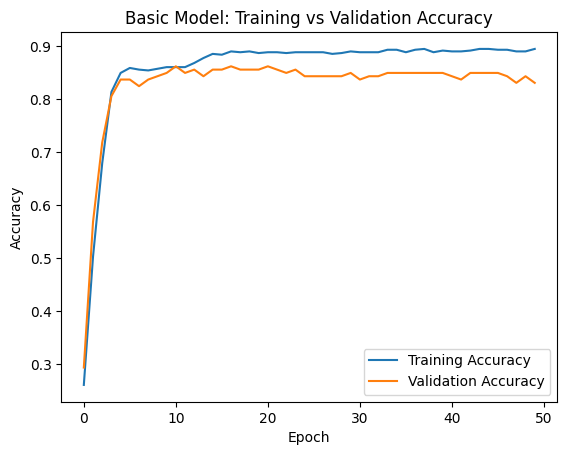

In [ ]:
# Plot training accuracy
plt.plot(basic_history.history["accuracy"], label="Training Accuracy")

# Plot validation accuracy
plt.plot(basic_history.history["val_accuracy"], label="Validation Accuracy")

# Add title
plt.title("Basic Model: Training vs Validation Accuracy")

# Add x-axis label
plt.xlabel("Epoch")

# Add y-axis label
plt.ylabel("Accuracy")

# Add legend
plt.legend()

# Show plot
plt.show()

**Step 11: Plot Basic Model Loss**

Loss shows error. If validation loss increases while training loss decreases, the model is overfitting.

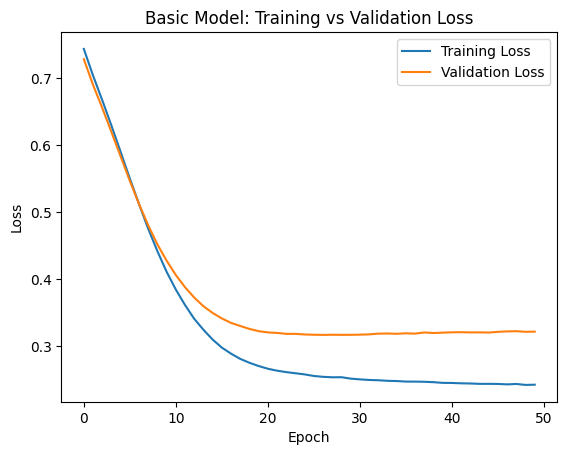

In [ ]:
# Plot training loss
plt.plot(basic_history.history["loss"], label="Training Loss")

# Plot validation loss
plt.plot(basic_history.history["val_loss"], label="Validation Loss")

# Add title
plt.title("Basic Model: Training vs Validation Loss")

# Add x-axis label
plt.xlabel("Epoch")

# Add y-axis label
plt.ylabel("Loss")

# Add legend
plt.legend()

# Show plot
plt.show()